In [1]:
import torch 
torch.set_default_dtype(torch.float64)
torch.manual_seed(42)
torch.use_deterministic_algorithms(True)

import numpy as np
import matplotlib.pyplot as plt

from src.kernels import *
from src.GPPW import *
from src.utils.smooth_hot import *
from data.repetitve_sine import *
from src.utils.plots import *

plt.style.use('default')
plt.rcParams.update({
	"text.usetex": True,
	"font.family": "serif",
	"figure.figsize": [12, 5]
})

def min_eigv(x):
	return torch.linalg.eigvalsh(x)[0].real.min()

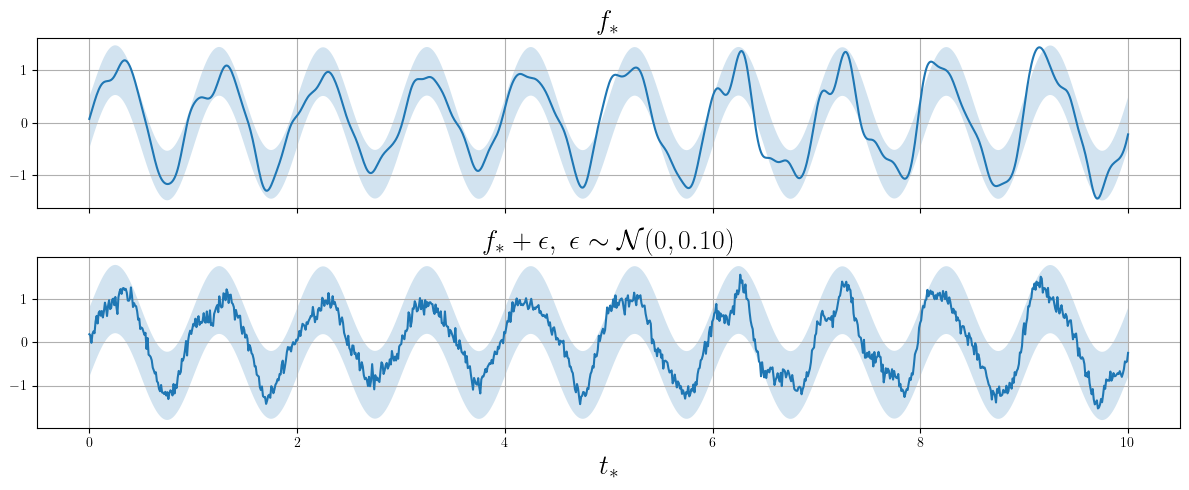

In [2]:
periodic = False
full_n = 100
full_r = 10

x_full, y_full, cycle_idcs, m, S = get_data(periodic, full_n, full_r)

stds = S.diag().sqrt()
_, axes = plt.subplots(2, 1, sharex=True, layout='tight')
axes[0].plot(x_full, y_full)
plot_condfidence_1d(x_full, m, 2 * S.diag().sqrt(), axes[0], alpha=0.2)
axes[0].grid(True)
axes[0].set_title(r'$f_*$', fontsize=20)

out_noise_plot = 0.1
axes[1].plot(x_full, y_full + out_noise_plot *  torch.randn_like(x_full))
plot_condfidence_1d(x_full, m, 2 * (S + out_noise_plot).diag().sqrt(), axes[1], alpha=0.2)
axes[1].grid(True)
axes[1].set_title(rf'$f_* + \epsilon,~\epsilon\sim \mathcal{{N}}(0, {out_noise_plot:.2f})$', 
	fontsize=20)
axes[1].set_xlabel(r'$t_*$', fontsize=20);

In [3]:
import pandas as pd
batches = [1, 2, 3, 5, 10]
models=[]

train_reps = full_r
n_train = 20
x_train, y_train = to_train(x_full, y_full, full_n, train_reps, n_train)

for i, b in enumerate(batches):
	model = GPPW(
		x_train, y_train.reshape(train_reps, -1, 1), 
		[PeriodicKernel(1.0)], PeriodicWeightKernel(1.0),
		learn_out_var=True
	)
	model.train()

	iterations = 100
	losses1 = model.fit(lr=0.1, iterations=iterations, batch_size=b)
	model.eval()
	model.train()
	losses2 = model.fit_weight(lr=0.1, iterations=iterations)
	models.append(model)

it: 99 - loss: -3.429e+02: 100%|██████████| 100/100 [00:00<00:00, 151.91it/s]


In [4]:
df = pd.DataFrame(
	index=batches, 
	columns=[
		r'MSE($y_\text{test}, \mu_\gamma$)', 
		r'MSE($\sqrt\diag\Sigma_\text{test}, \sqrt\diag\Sigma\gamma$)', 
		'kernels.0.l_raw', 'weight_kernel.l_raw', 'var_n_raw', 'var_o_raw', 
		'kernels.0.var_raw', 'weight_kernel.var_raw'
		])

for i, b in enumerate(batches):
	model = models[i]
	mu, cov = model.generate(x_full)
	df.iloc[i, 0] = ((mu - m) ** 2).mean().item().__format__('.2e')
	df.iloc[i, 0] = f'\\num{{{df.iloc[i, 0]}}}'
	df.iloc[i, 1] = ((cov.diag().sqrt() - S.diag().sqrt())**2).mean().item().__format__('.2e')
	df.iloc[i, 1] = f'\\num{{{df.iloc[i, 1]}}}'


	for name, param in model.named_parameters():
		if name in df.columns:
			param = make_positive(param)
			df.loc[b, name] = param.item().__round__(3) #.__str__()
df

,"MSE($y_\text{test}, \mu_\gamma$)","MSE($\sqrt\diag\Sigma_\text{test}, \sqrt\diag\Sigma\gamma$)",kernels.0.l_raw,weight_kernel.l_raw,var_n_raw,var_o_raw,kernels.0.var_raw,weight_kernel.var_raw
1,\num{1.84e-02},\num{3.18e-02},0.616,0.508,0.005,0.037,0.474,8.034
2,\num{1.34e-02},\num{3.52e-04},1.012,0.592,0.327,0.0,0.602,5.687
3,\num{1.31e-02},\num{1.19e-03},1.012,0.606,0.416,0.0,0.658,5.359
5,\num{1.24e-02},\num{2.40e-03},1.145,0.611,0.453,0.0,0.68,5.974
10,\num{1.27e-02},\num{2.58e-03},0.985,0.62,0.509,0.0,0.568,5.178


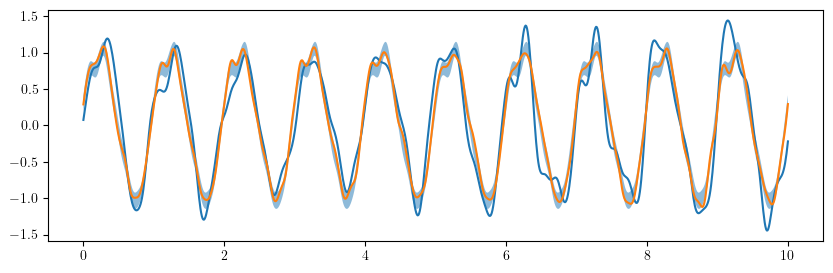

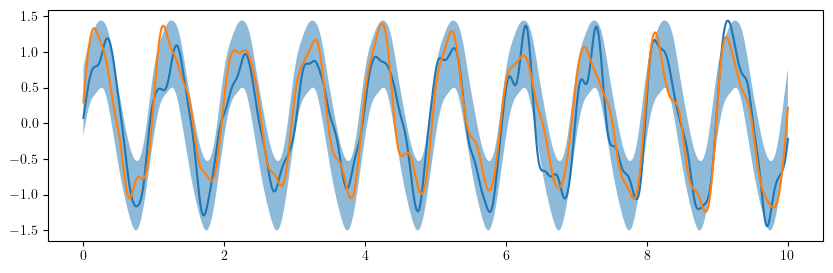

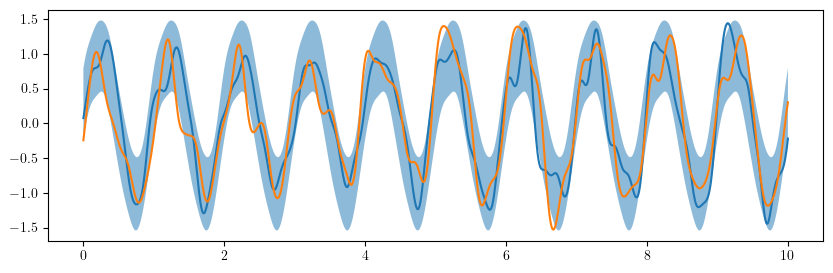

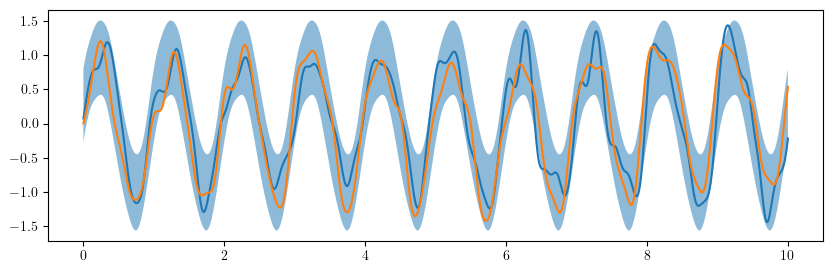

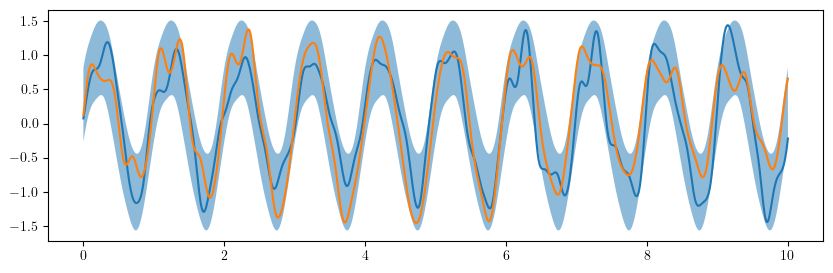

In [5]:
for model in models:
	with torch.no_grad():
		mu, cov = model.generate(x_full, with_noise=False)
	s = mu + model.cholesky(cov) @ torch.randn_like(mu)
	plt.figure(figsize=[10, 3])
	plt.plot(x_full, y_full)
	plt.plot(x_full, s)
	# plt.plot(x_full, mu)
	stds = cov.diag().sqrt()
	mu = mu.squeeze()
	plt.fill_between(x_full.squeeze(), mu + 2 * stds, mu - 2 * stds, alpha=0.5)

In [6]:
noise_levels = [0.01, 0.05, 0.1, 0.3, 0.5]
models_e = []

train_reps = full_r
n_train = 20

for i, b in enumerate(noise_levels):
	y_train_noise = y_train.clone() + b * torch.randn_like(y_train)
	model = GPPW(
		x_train, y_train_noise.reshape(train_reps, -1, 1), 
		[PeriodicKernel(1.0)], PeriodicWeightKernel(1.0),
		learn_out_var=True
	)
	iterations = 100
	model.train()
	losses = model.fit(lr=0.1, iterations=iterations, batch_size=2)
	losses = model.fit_weight(lr=0.1, iterations=iterations)
	model.eval()
	models_e.append(model)

it: 99 - loss: 1.726e+02: 100%|██████████| 100/100 [00:00<00:00, 153.57it/s]


In [7]:
df = pd.DataFrame(
	index=noise_levels, 
	columns=[
		r'MSE($y_\text{test}, \mu_\gamma$)', 
		r'MSE($\sqrt\diag\Sigma_\text{test}, \sqrt\diag\Sigma\gamma$)', 
		'kernels.0.l_raw', 'weight_kernel.l_raw', 'var_n_raw', 'var_o_raw', 
		'kernels.0.var_raw', 'weight_kernel.var_raw'
		])

for i, b in enumerate(noise_levels):
	model = models_e[i]
	mu, cov = model.generate(x_full, with_noise=True)
	df.iloc[i, 0] = ((mu - m) ** 2).mean().item().__format__('.2e')
	df.iloc[i, 0] = f'\\num{{{df.iloc[i, 0]}}}'

	extra_noise = (b * torch.eye(len(x_full))).pow(2)
	df.iloc[i, 1] = ((cov.diag().sqrt() - (S+extra_noise).diag().sqrt())**2).mean().item().__format__('.2e')
	df.iloc[i, 1] = f'\\num{{{df.iloc[i, 1]}}}'

	for name, param in model.named_parameters():
		if name in df.columns:
			param = make_positive(param)
			df.loc[b, name] = param.item().__round__(3) #.__str__()
df

,"MSE($y_\text{test}, \mu_\gamma$)","MSE($\sqrt\diag\Sigma_\text{test}, \sqrt\diag\Sigma\gamma$)",kernels.0.l_raw,weight_kernel.l_raw,var_n_raw,var_o_raw,kernels.0.var_raw,weight_kernel.var_raw
0.01,\num{1.32e-02},\num{4.00e-04},1.006,0.581,0.332,0.0,0.571,5.729
0.05,\num{1.47e-02},\num{3.87e-04},0.951,0.526,0.378,0.003,0.652,4.855
0.10,\num{9.57e-03},\num{3.31e-04},1.037,0.58,0.409,0.011,0.714,4.638
0.30,\num{1.06e-02},\num{1.36e-03},1.62,0.384,1.113,0.089,0.873,1.179
0.50,\num{2.53e-02},\num{1.97e-03},1.142,0.012,3.342,0.222,0.666,2.002


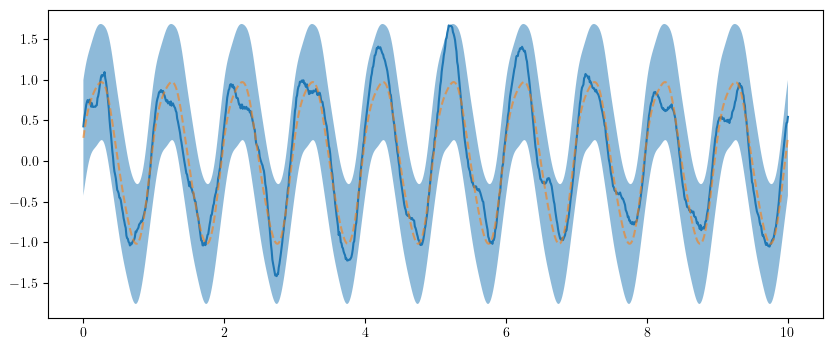

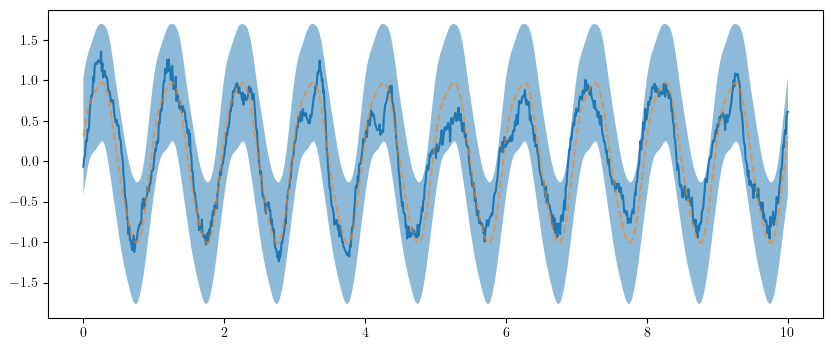

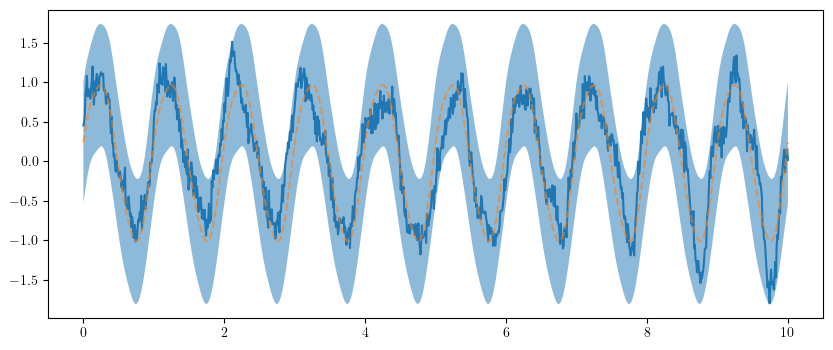

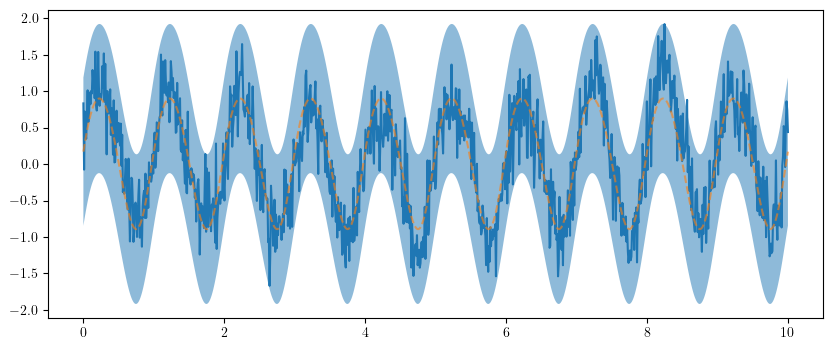

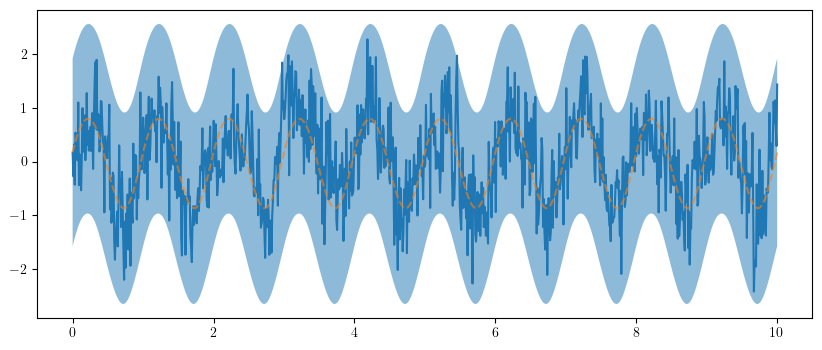

In [8]:
for i, model in enumerate(models_e):
	with torch.no_grad():
		mu, cov = model.generate(x_full, with_noise=True)
	s = mu + model.cholesky(cov) @ torch.randn_like(mu)

	plt.figure(figsize=[10, 4])

	plt.plot(x_full, s)
	plt.plot(x_full, mu, linestyle='--', alpha=0.6)
	stds = cov.diag().sqrt()
	mu = mu.squeeze()
	plt.fill_between(x_full.squeeze(), mu + 3 * stds, mu - 3 * stds, alpha=0.5)

In [9]:
example_model = models[1]
example_model.eval()
x_test = x_full + 20
with_noise = False
with torch.no_grad():
	mu, cov = example_model.generate(x_test, with_noise=with_noise)
	_, covp = example_model.predict(x_test, with_noise=with_noise)

for (name, param) in example_model.named_parameters():
	print(f'{name}\t{make_positive(param).item():.3e}')

var_n_raw	3.271e-01
var_o_raw	1.690e-04
kernels.0.l_raw	1.012e+00
kernels.0.var_raw	6.017e-01
weight_kernel.l_raw	5.924e-01
weight_kernel.var_raw	5.687e+00


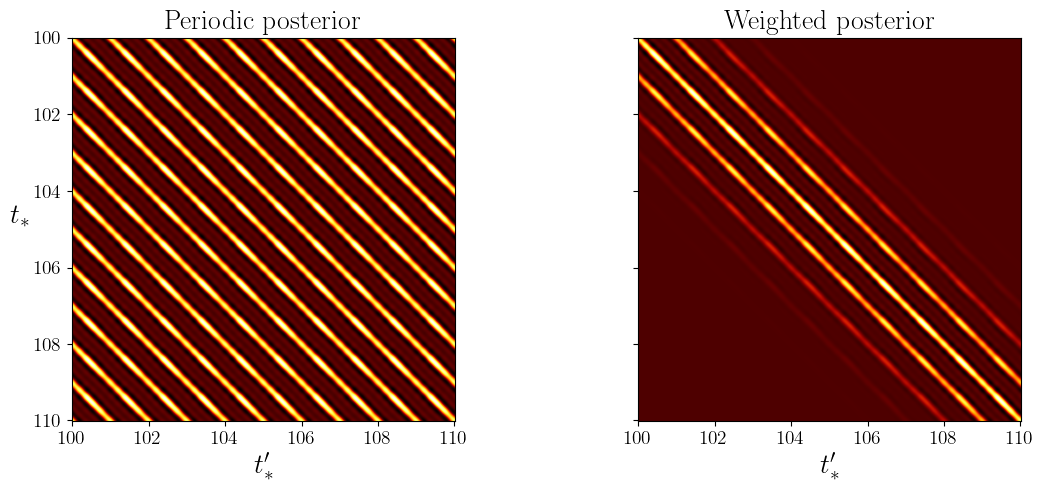

In [10]:
fig, axes = plt.subplots(1, 2, sharey=True)

axes[0].imshow(covp, cmap=smooth_hot())

# axes[0].set_xticks([0, 250, 500, 750, 998], [20.0, 22.5, 25.0, 27.5, 30.0])
# axes[0].set_yticks([0, 250, 500, 750, 997], [20.0, 22.5, 25.0, 27.5, 30.0])
axes[0].set_xlabel('$t_*\'$', fontsize=20)
axes[0].set_ylabel('$t_*$', fontsize=20, rotation=0, labelpad=10)

idcs = [i * 1000 // 5 for i in range(6)]
idcs[-1] -= 2
labels = [100 + i * 2 for i in range(6)]
axes[0].set_xticks(idcs, labels)
axes[0].set_yticks(idcs, labels)
axes[0].set_yticklabels([str(l) for l in labels], fontsize=14)
axes[0].set_xticklabels([str(l) for l in labels], fontsize=14)

axes[0].set_title('Periodic posterior', fontsize=20)

#####################

axes[1].imshow(cov, cmap=smooth_hot())

axes[1].set_xticks(idcs, labels)
axes[1].set_yticks(idcs, labels)
axes[1].set_yticklabels([str(l) for l in labels], fontsize=14)
axes[1].set_xticklabels([str(l) for l in labels], fontsize=14)

axes[1].set_xlabel('$t_*\'$', fontsize=20)

axes[1].set_title('Weighted posterior', fontsize=20)

plt.tight_layout()

<>:11: SyntaxWarning: invalid escape sequence '\h'
<>:11: SyntaxWarning: invalid escape sequence '\h'
C:\Users\elias\AppData\Local\Temp\ipykernel_48208\3857803916.py:11: SyntaxWarning: invalid escape sequence '\h'
  label='$\hat\mu$')
C:\Users\elias\AppData\Local\Temp\ipykernel_48208\3857803916.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(ax.get_yticklabels(), fontsize=14)
C:\Users\elias\AppData\Local\Temp\ipykernel_48208\3857803916.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), fontsize=14)


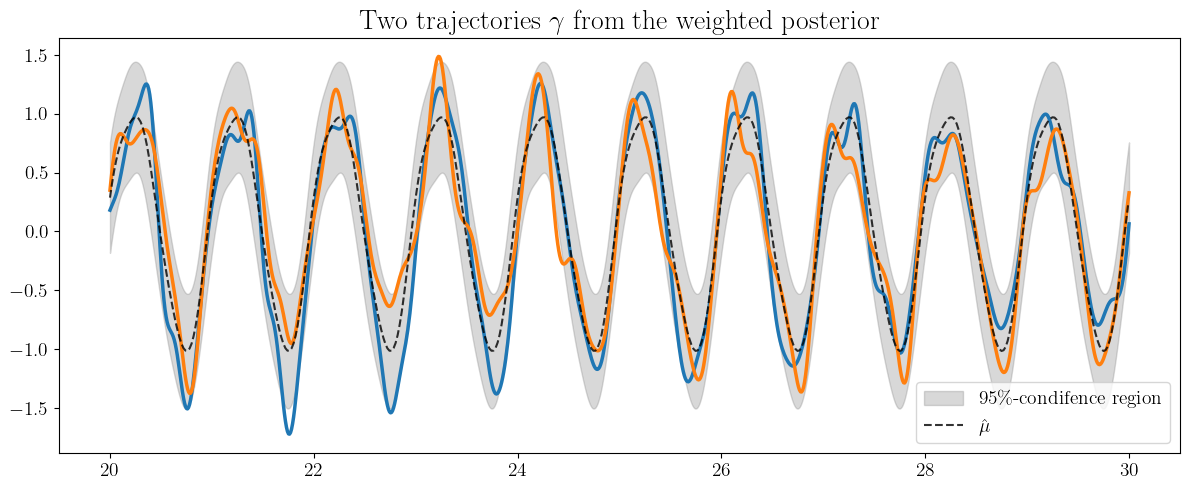

In [11]:
stds = cov.diag().sqrt()
plt.fill_between(x_test.squeeze(), 
	(mu.squeeze() - 2 * stds).flatten(),
	(mu.squeeze() + 2 * stds).flatten(), color='gray', alpha=0.3, 
	label=r'$95\%$-condifence region')

plt.plot(x_test, mu + model.cholesky(cov) @ torch.randn_like(mu), linewidth=2.5)
plt.plot(x_test, mu + model.cholesky(cov) @ torch.randn_like(mu), linewidth=2.5)

plt.plot(x_test[::2], mu[::2], linewidth=1.5, linestyle='--', c='k', alpha=0.8,
	label='$\hat\mu$')

ax = plt.gca()
ax.set_yticklabels(ax.get_yticklabels(), fontsize=14)
ax.set_xticklabels(ax.get_xticklabels(), fontsize=14)

plt.title(r'Two trajectories $\gamma$ from the weighted posterior', fontsize=20)
plt.legend(fontsize=14, loc='lower right')

plt.tight_layout()